# Revised multi-seed damped oscillator experiment

## Intended interpretation

The main comparison is:

1. **ResNet (untied, h=64)**  
2. **NODE-Euler (shared vector field, fixed step)**  
3. **NODE-RK4 (shared vector field, fixed step)**  

The additional **ResNet (parameter-matched)** baseline is a fairness check, not the original main comparison.


In [1]:
import os
import sys
import json
import time
import copy
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


## Runtime settings

The notebook is written to run on CPU and to save outputs in a local `results/...` folder, so it does not depend on any external directory layout.


In [13]:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
try:
    torch.set_num_threads(1)
except Exception as e:
    print("torch.set_num_threads warning:", e)
try:
    torch.set_num_interop_threads(1)
except Exception as e:
    print("torch.set_num_interop_threads warning:", e)

device = torch.device("cpu")
print("device:", device)


torch.set_num_interop_threads warning: Error: cannot set number of interop threads after parallel work has started or set_num_interop_threads called
device: cpu


## Experimental methodology

This notebook uses a **fixed-step** realization on purpose. The goal is to isolate the architectural effect of shared continuous dynamics from the extra variability introduced by adaptive error control.

The damped oscillator is a **smooth, non-stiff, favorable regime** for continuous-depth models. That makes it a good first benchmark, but it also means any positive result here should be interpreted narrowly.

The comparison therefore probes an **inductive-bias tradeoff**:
- the ResNet is **untied across depth**
- the NODEs use **one shared vector field**


In [14]:
# ---------------------------------------------------------
# User-adjustable experiment settings
# ---------------------------------------------------------
SEEDS = [0, 1, 2, 3, 4]

# Physical parameters of the damped oscillator
OMEGA = 2.0
GAMMA = 0.35

# Time grid
T0, T1 = 0.0, 10.0
N_TIME = 51
T_EVAL = np.linspace(T0, T1, N_TIME)
DT = float(T_EVAL[1] - T_EVAL[0])

# Dataset sizes
N_TRAIN = 256
N_VAL = 64
N_TEST = 64

# Initial-condition domain
INIT_LOW = np.array([-2.5, -2.5], dtype=np.float64)
INIT_HIGH = np.array([2.5, 2.5], dtype=np.float64)

# Optimization
BATCH_SIZE = 32
EPOCHS = 150
LR = 1e-3
WEIGHT_DECAY = 1e-6

# Architecture settings
STATE_DIM = 2
SHARED_HIDDEN_DIM = 64
UNTIED_RESNET_HIDDEN_DIM = 64
MATCHED_RESNET_HIDDEN_DIM = 7
RESNET_BLOCKS = N_TIME - 1

# Bookkeeping / outputs
SAVE_HISTORIES = True
SAVE_MODEL_STATE_DICTS = True

RESULTS_DIR = Path("results/damped_oscillator_multiseed_revised")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_SPECS = {
    "resnet": {
        "label": "ResNet (untied, h=64)",
        "family": "discrete",
        "parameter_sharing": "untied",
        "hidden_dim": UNTIED_RESNET_HIDDEN_DIM,
        "steps": RESNET_BLOCKS,
        "operator_eval_kind": "residual_block",
        "operator_evals_per_traj_forward": RESNET_BLOCKS,
        "is_main_comparison": True,
        "is_fairness_check": False,
    },
    "resnet_matched": {
        "label": "ResNet (untied, parameter-matched)",
        "family": "discrete",
        "parameter_sharing": "untied",
        "hidden_dim": MATCHED_RESNET_HIDDEN_DIM,
        "steps": RESNET_BLOCKS,
        "operator_eval_kind": "residual_block",
        "operator_evals_per_traj_forward": RESNET_BLOCKS,
        "is_main_comparison": False,
        "is_fairness_check": True,
    },
    "node_euler": {
        "label": "NODE-Euler (shared vector field)",
        "family": "continuous_fixed_step",
        "parameter_sharing": "shared",
        "hidden_dim": SHARED_HIDDEN_DIM,
        "steps": RESNET_BLOCKS,
        "operator_eval_kind": "vector_field",
        "operator_evals_per_traj_forward": RESNET_BLOCKS,
        "is_main_comparison": True,
        "is_fairness_check": False,
    },
    "node_rk4": {
        "label": "NODE-RK4 (shared vector field)",
        "family": "continuous_fixed_step",
        "parameter_sharing": "shared",
        "hidden_dim": SHARED_HIDDEN_DIM,
        "steps": RESNET_BLOCKS,
        "operator_eval_kind": "vector_field",
        "operator_evals_per_traj_forward": 4 * RESNET_BLOCKS,
        "is_main_comparison": True,
        "is_fairness_check": False,
    },
}

MODEL_ORDER = ["resnet", "resnet_matched", "node_euler", "node_rk4"]
MAIN_MODEL_ORDER = ["resnet", "node_euler", "node_rk4"]
FAIRNESS_MODEL_ORDER = ["resnet_matched", "node_euler", "node_rk4"]


print("DT =", DT)
print("seeds =", SEEDS)


DT = 0.2
seeds = [0, 1, 2, 3, 4]


## Reproducibility helpers and experiment metadata

The exported metadata JSON is meant to support a shared methods chapter or section across experiments.


In [15]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def experiment_metadata_dict():
    return {
        "seeds": SEEDS,
        "omega": OMEGA,
        "gamma": GAMMA,
        "t0": T0,
        "t1": T1,
        "n_time": N_TIME,
        "dt": DT,
        "n_train": N_TRAIN,
        "n_val": N_VAL,
        "n_test": N_TEST,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "state_dim": STATE_DIM,
        "shared_hidden_dim": SHARED_HIDDEN_DIM,
        "untied_resnet_hidden_dim": UNTIED_RESNET_HIDDEN_DIM,
        "matched_resnet_hidden_dim": MATCHED_RESNET_HIDDEN_DIM,
        "device": str(device),
        "python": sys.version,
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scipy": scipy.__version__,
        "torch": torch.__version__,
        "model_specs": MODEL_SPECS,
        "framing": (
            "This notebook compares one untied residual baseline against simple fixed-step shared-vector-field "
            "baselines on a controlled, low-dimensional, smooth, non-stiff dynamical system. "
            "The fixed-step realizations are used intentionally to isolate architectural structure from adaptive error control."
        ),
    }


## True system and synthetic data generation

The ground-truth trajectories are generated with a high-accuracy `DOP853` solve and then sampled on a fixed grid of 51 time points over `[0, 10]`.


In [16]:
def damped_oscillator(t, z, omega=OMEGA, gamma=GAMMA):
    x, v = z
    dx = v
    dv = -(omega ** 2) * x - gamma * v
    return np.array([dx, dv], dtype=np.float64)

def solve_true_trajectory(z0, t_eval=T_EVAL, omega=OMEGA, gamma=GAMMA):
    sol = solve_ivp(
        fun=lambda t, z: damped_oscillator(t, z, omega=omega, gamma=gamma),
        t_span=(float(t_eval[0]), float(t_eval[-1])),
        y0=np.asarray(z0, dtype=np.float64),
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
    )
    if not sol.success:
        raise RuntimeError(f"Trajectory generation failed: {sol.message}")
    return sol.y.T.astype(np.float32)

def sample_initial_conditions(n, low=INIT_LOW, high=INIT_HIGH):
    return np.random.uniform(low=low, high=high, size=(n, 2)).astype(np.float32)

def make_dataset(n_samples):
    z0s = sample_initial_conditions(n_samples)
    trajectories = np.stack([solve_true_trajectory(z0) for z0 in z0s], axis=0)
    return z0s, trajectories

def make_dataloaders(train_z0, train_traj, val_z0, val_traj, test_z0, test_traj):
    train_ds = TensorDataset(torch.from_numpy(train_z0), torch.from_numpy(train_traj))
    val_ds = TensorDataset(torch.from_numpy(val_z0), torch.from_numpy(val_traj))
    test_ds = TensorDataset(torch.from_numpy(test_z0), torch.from_numpy(test_traj))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, val_loader, test_loader


## Model definitions

The notebook now stores explicit metadata for:
- model family
- parameter-sharing scheme
- exact forward operator-evaluations per trajectory

This makes the fairness limitation visible in the results table rather than only in prose.


In [17]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=2, activation=nn.Tanh):
        super().__init__()
        layers = []
        dims = [in_dim] + [hidden_dim] * depth + [out_dim]
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(activation())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class ResidualBlock(nn.Module):
    def __init__(self, state_dim=STATE_DIM, hidden_dim=UNTIED_RESNET_HIDDEN_DIM):
        super().__init__()
        self.f = MLP(state_dim, hidden_dim, state_dim, depth=2, activation=nn.Tanh)

    def forward(self, z):
        return z + DT * self.f(z)

class ResNetTrajectoryModel(nn.Module):
    def __init__(self, num_blocks=RESNET_BLOCKS, state_dim=STATE_DIM, hidden_dim=UNTIED_RESNET_HIDDEN_DIM):
        super().__init__()
        self.blocks = nn.ModuleList([
            ResidualBlock(state_dim=state_dim, hidden_dim=hidden_dim)
            for _ in range(num_blocks)
        ])

    def forward(self, z0):
        zs = [z0]
        z = z0
        for block in self.blocks:
            z = block(z)
            zs.append(z)
        return torch.stack(zs, dim=1)

class VectorField(nn.Module):
    def __init__(self, state_dim=STATE_DIM, hidden_dim=SHARED_HIDDEN_DIM):
        super().__init__()
        self.f = MLP(state_dim, hidden_dim, state_dim, depth=2, activation=nn.Tanh)

    def forward(self, z):
        return self.f(z)

class FixedStepNODE(nn.Module):
    def __init__(self, method="euler", state_dim=STATE_DIM, hidden_dim=SHARED_HIDDEN_DIM):
        super().__init__()
        self.method = method.lower()
        self.vf = VectorField(state_dim=state_dim, hidden_dim=hidden_dim)

    def step_euler(self, z, dt):
        return z + dt * self.vf(z)

    def step_rk4(self, z, dt):
        k1 = self.vf(z)
        k2 = self.vf(z + 0.5 * dt * k1)
        k3 = self.vf(z + 0.5 * dt * k2)
        k4 = self.vf(z + dt * k3)
        return z + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

    def forward(self, z0):
        zs = [z0]
        z = z0
        for _ in range(N_TIME - 1):
            if self.method == "euler":
                z = self.step_euler(z, DT)
            elif self.method == "rk4":
                z = self.step_rk4(z, DT)
            else:
                raise ValueError(f"Unknown method: {self.method}")
            zs.append(z)
        return torch.stack(zs, dim=1)

def build_models():
    return {
        "resnet": ResNetTrajectoryModel(hidden_dim=UNTIED_RESNET_HIDDEN_DIM),
        "resnet_matched": ResNetTrajectoryModel(hidden_dim=MATCHED_RESNET_HIDDEN_DIM),
        "node_euler": FixedStepNODE(method="euler", hidden_dim=SHARED_HIDDEN_DIM),
        "node_rk4": FixedStepNODE(method="rk4", hidden_dim=SHARED_HIDDEN_DIM),
    }


## Metrics and bookkeeping

In addition to trajectory MSE, the notebook records:
- relative trajectory \(L^2\) error
- final-state RMSE
- separate fit-time and validation-time accounting
- exact forward operator-evaluation counts

For the fixed-step NODEs, the forward operator count is exact:
- Euler: 1 vector-field evaluation per step
- RK4: 4 vector-field evaluations per step

For the ResNets, the analogous quantity is the number of residual-block evaluations per trajectory.


In [18]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def mse_loss(pred, target):
    return torch.mean((pred - target) ** 2)

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    total_loss = 0.0
    total_n = 0
    preds_all = []
    targets_all = []

    for z0, traj in loader:
        z0 = z0.to(device)
        traj = traj.to(device)

        pred = model(z0)
        loss = mse_loss(pred, traj)

        batch_size = z0.shape[0]
        total_loss += loss.item() * batch_size
        total_n += batch_size

        preds_all.append(pred.cpu())
        targets_all.append(traj.cpu())

    preds_all = torch.cat(preds_all, dim=0).numpy()
    targets_all = torch.cat(targets_all, dim=0).numpy()
    return total_loss / total_n, preds_all, targets_all

def relative_l2_error(pred, target):
    return np.linalg.norm(pred - target) / np.linalg.norm(target)

def final_state_rmse(pred, target):
    diff = pred[:, -1, :] - target[:, -1, :]
    return np.sqrt(np.mean(diff ** 2))


## Training utility

The timer is split into:
- `fit_time_sec`
- `val_time_sec`
- `total_loop_time_sec`

so the reported optimization cost is not conflated with repeated validation sweeps.


In [19]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
    }

    best_state = None
    best_val = float("inf")

    fit_time = 0.0
    val_time = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total_n = 0

        t_fit0 = time.perf_counter()
        for z0, traj in train_loader:
            z0 = z0.to(device)
            traj = traj.to(device)

            optimizer.zero_grad()
            pred = model(z0)
            loss = mse_loss(pred, traj)
            loss.backward()
            optimizer.step()

            batch_size = z0.shape[0]
            running_loss += loss.item() * batch_size
            total_n += batch_size
        fit_time += time.perf_counter() - t_fit0

        train_loss = running_loss / total_n

        t_val0 = time.perf_counter()
        val_loss, _, _ = evaluate_model(model, val_loader)
        val_time += time.perf_counter() - t_val0

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    timing = {
        "fit_time_sec": fit_time,
        "val_time_sec": val_time,
        "total_loop_time_sec": fit_time + val_time,
    }
    return model, pd.DataFrame(history), timing


## One full seed run

For each seed, the notebook:
1. regenerates train / validation / test data
2. rebuilds all model instances
3. trains each model from scratch
4. saves metrics, histories, and optional checkpoints

The checkpoints are used later for the adaptive-solver probe on the learned NODE vector fields.


In [20]:
def save_model_checkpoint(model_name, seed, trained_model):
    if not SAVE_MODEL_STATE_DICTS:
        return None
    ckpt_path = RESULTS_DIR / f"{model_name}_seed{seed}.pt"
    torch.save({"state_dict": trained_model.state_dict()}, ckpt_path)
    return ckpt_path

def run_one_seed(seed: int):
    set_seed(seed)

    train_z0, train_traj = make_dataset(N_TRAIN)
    val_z0, val_traj = make_dataset(N_VAL)
    test_z0, test_traj = make_dataset(N_TEST)

    train_loader, val_loader, test_loader = make_dataloaders(
        train_z0, train_traj, val_z0, val_traj, test_z0, test_traj
    )

    models = build_models()

    seed_rows = []
    seed_histories = {}

    for name in MODEL_ORDER:
        model = models[name]
        spec = MODEL_SPECS[name]

        trained_model, history_df, timing = train_model(model, train_loader, val_loader)

        train_loss, train_pred, train_true = evaluate_model(trained_model, train_loader)
        val_loss, val_pred, val_true = evaluate_model(trained_model, val_loader)
        test_loss, test_pred, test_true = evaluate_model(trained_model, test_loader)

        n_train_traj_fit = EPOCHS * len(train_loader.dataset)
        n_val_traj_during_fit = EPOCHS * len(val_loader.dataset)
        n_final_eval_traj = len(train_loader.dataset) + len(val_loader.dataset) + len(test_loader.dataset)
        op_evals_per_traj = spec["operator_evals_per_traj_forward"]

        ckpt_path = save_model_checkpoint(name, seed, trained_model)

        row = {
            "seed": seed,
            "model": name,
            "label": spec["label"],
            "family": spec["family"],
            "parameter_sharing": spec["parameter_sharing"],
            "is_main_comparison": spec["is_main_comparison"],
            "is_fairness_check": spec["is_fairness_check"],
            "parameters": count_parameters(trained_model),
            "steps": spec["steps"],
            "operator_eval_kind": spec["operator_eval_kind"],
            "operator_evals_per_traj_forward": op_evals_per_traj,
            "fit_forward_operator_evals_total": op_evals_per_traj * n_train_traj_fit,
            "fit_plus_epoch_val_forward_operator_evals_total": op_evals_per_traj * (n_train_traj_fit + n_val_traj_during_fit),
            "all_logged_forward_operator_evals_total": op_evals_per_traj * (n_train_traj_fit + n_val_traj_during_fit + n_final_eval_traj),
            "fit_time_sec": timing["fit_time_sec"],
            "val_time_sec": timing["val_time_sec"],
            "total_loop_time_sec": timing["total_loop_time_sec"],
            "train_loss": train_loss,
            "val_loss": val_loss,
            "test_loss": test_loss,
            "test_rel_l2_err": relative_l2_error(test_pred, test_true),
            "test_final_state_rmse": final_state_rmse(test_pred, test_true),
            "checkpoint_path": str(ckpt_path) if ckpt_path is not None else "",
        }
        seed_rows.append(row)

        if SAVE_HISTORIES:
            hist = history_df.copy()
            hist["seed"] = seed
            hist["model"] = name
            hist["label"] = spec["label"]
            seed_histories[name] = hist

    return pd.DataFrame(seed_rows), seed_histories


## Run the revised multi-seed experiment


In [21]:
all_results = []
all_histories = []

for seed in SEEDS:
    print("=" * 80)
    print(f"Running seed {seed}")
    seed_df, seed_histories = run_one_seed(seed)
    all_results.append(seed_df)

    if SAVE_HISTORIES:
        for history_df in seed_histories.values():
            all_histories.append(history_df)

results_df = pd.concat(all_results, ignore_index=True)

if SAVE_HISTORIES and len(all_histories) > 0:
    histories_df = pd.concat(all_histories, ignore_index=True)
else:
    histories_df = None

results_df


Running seed 0
Running seed 1
Running seed 2
Running seed 3
Running seed 4


,seed,model,label,family,parameter_sharing,is_main_comparison,is_fairness_check,parameters,steps,operator_eval_kind,...,all_logged_forward_operator_evals_total,fit_time_sec,val_time_sec,total_loop_time_sec,train_loss,val_loss,test_loss,test_rel_l2_err,test_final_state_rmse,checkpoint_path
0,0,resnet,"ResNet (untied, h=64)",discrete,untied,True,False,224100,50,residual_block,...,2419200,7.561313,0.529293,8.090607,0.089169,0.102015,0.091645,0.315460,0.131318,results/damped_oscillator_multiseed_revised/re...
1,0,resnet_matched,"ResNet (untied, parameter-matched)",discrete,untied,False,True,4650,50,residual_block,...,2419200,5.703569,0.294900,5.998469,0.407567,0.437686,0.421421,0.676467,0.130537,results/damped_oscillator_multiseed_revised/re...
2,0,node_euler,NODE-Euler (shared vector field),continuous_fixed_step,shared,True,False,4482,50,vector_field,...,2419200,4.153728,0.466379,4.620107,0.001528,0.001535,0.001279,0.037264,0.016078,results/damped_oscillator_multiseed_revised/no...
3,0,node_rk4,NODE-RK4 (shared vector field),continuous_fixed_step,shared,True,False,4482,50,vector_field,...,9676800,17.221161,1.908267,19.129428,0.001123,0.001253,0.001073,0.034134,0.010358,results/damped_oscillator_multiseed_revised/no...
4,1,resnet,"ResNet (untied, h=64)",discrete,untied,True,False,224100,50,residual_block,...,2419200,7.615693,0.540889,8.156581,0.121839,0.108437,0.135586,0.399902,0.131603,results/damped_oscillator_multiseed_revised/re...
5,1,resnet_matched,"ResNet (untied, parameter-matched)",discrete,untied,False,True,4650,50,residual_block,...,2419200,5.707617,0.298168,6.005785,0.286475,0.266614,0.278989,0.573640,0.170938,results/damped_oscillator_multiseed_revised/re...
6,1,node_euler,NODE-Euler (shared vector field),continuous_fixed_step,shared,True,False,4482,50,vector_field,...,2419200,4.255814,0.474616,4.730430,0.002397,0.002331,0.001566,0.042976,0.013121,results/damped_oscillator_multiseed_revised/no...
7,1,node_rk4,NODE-RK4 (shared vector field),continuous_fixed_step,shared,True,False,4482,50,vector_field,...,9676800,16.935044,1.922830,18.857874,0.002056,0.002143,0.001316,0.039392,0.014858,results/damped_oscillator_multiseed_revised/no...
8,2,resnet,"ResNet (untied, h=64)",discrete,untied,True,False,224100,50,residual_block,...,2419200,7.520983,0.537751,8.058733,0.074150,0.075336,0.077704,0.283182,0.116624,results/damped_oscillator_multiseed_revised/re...
9,2,resnet_matched,"ResNet (untied, parameter-matched)",discrete,untied,False,True,4650,50,residual_block,...,2419200,5.897286,0.305679,6.202965,0.280592,0.287352,0.302344,0.558593,0.146657,results/damped_oscillator_multiseed_revised/re...


## Aggregate means and standard deviations across seeds


In [22]:
summary_df = (
    results_df.groupby(["model", "label", "family", "parameter_sharing", "is_main_comparison", "is_fairness_check"], as_index=False)
    .agg(
        parameters=("parameters", "first"),
        steps=("steps", "first"),
        operator_eval_kind=("operator_eval_kind", "first"),
        operator_evals_per_traj_forward=("operator_evals_per_traj_forward", "first"),
        fit_forward_operator_evals_total_mean=("fit_forward_operator_evals_total", "mean"),
        fit_forward_operator_evals_total_std=("fit_forward_operator_evals_total", "std"),
        fit_time_mean=("fit_time_sec", "mean"),
        fit_time_std=("fit_time_sec", "std"),
        val_time_mean=("val_time_sec", "mean"),
        val_time_std=("val_time_sec", "std"),
        total_loop_time_mean=("total_loop_time_sec", "mean"),
        total_loop_time_std=("total_loop_time_sec", "std"),
        train_loss_mean=("train_loss", "mean"),
        train_loss_std=("train_loss", "std"),
        val_loss_mean=("val_loss", "mean"),
        val_loss_std=("val_loss", "std"),
        test_loss_mean=("test_loss", "mean"),
        test_loss_std=("test_loss", "std"),
        test_rel_l2_err_mean=("test_rel_l2_err", "mean"),
        test_rel_l2_err_std=("test_rel_l2_err", "std"),
        test_final_state_rmse_mean=("test_final_state_rmse", "mean"),
        test_final_state_rmse_std=("test_final_state_rmse", "std"),
    )
)

summary_df = summary_df.set_index("model").loc[MODEL_ORDER].reset_index()
summary_df


,model,label,family,parameter_sharing,is_main_comparison,is_fairness_check,parameters,steps,operator_eval_kind,operator_evals_per_traj_forward,...,train_loss_mean,train_loss_std,val_loss_mean,val_loss_std,test_loss_mean,test_loss_std,test_rel_l2_err_mean,test_rel_l2_err_std,test_final_state_rmse_mean,test_final_state_rmse_std
0,resnet,"ResNet (untied, h=64)",discrete,untied,True,False,224100,50,residual_block,50,...,0.086281,0.021150,0.090991,0.015814,0.090118,0.026809,0.317419,0.048224,0.121472,0.009212
1,resnet_matched,"ResNet (untied, parameter-matched)",discrete,untied,False,True,4650,50,residual_block,50,...,0.318695,0.053191,0.359314,0.110481,0.316983,0.060070,0.597083,0.047239,0.139437,0.019818
2,node_euler,NODE-Euler (shared vector field),continuous_fixed_step,shared,True,False,4482,50,vector_field,50,...,0.003476,0.002052,0.004374,0.002308,0.002748,0.001714,0.053572,0.016359,0.024747,0.011641
3,node_rk4,NODE-RK4 (shared vector field),continuous_fixed_step,shared,True,False,4482,50,vector_field,200,...,0.002683,0.002533,0.003425,0.002506,0.002226,0.002370,0.045685,0.020435,0.016988,0.009272


## Save raw runs, summaries, histories, and experiment metadata


In [24]:
results_path = RESULTS_DIR / "all_runs.csv"
summary_path = RESULTS_DIR / "summary_mean_std.csv"
meta_path = RESULTS_DIR / "experiment_metadata.json"

results_df.to_csv(results_path, index=False)
summary_df.to_csv(summary_path, index=False)

with open(meta_path, "w") as f:
    json.dump(experiment_metadata_dict(), f, indent=2)


if histories_df is not None:
    histories_path = RESULTS_DIR / "all_histories.csv"
    histories_df.to_csv(histories_path, index=False)


## Summary tables

The first table is the **main comparison**.  
The second table is the **fairness check**, where the parameter-matched ResNet is compared against the shared-flow NODE baselines.


In [25]:
def add_mean_pm_std_strings(df, metric_bases):
    out = df.copy()
    for base in metric_bases:
        mean_col = f"{base}_mean"
        std_col = f"{base}_std"
        if mean_col in out.columns and std_col in out.columns:
            out[f"{base}_mean_pm_std"] = out.apply(
                lambda r: f"{r[mean_col]:.6f} ± {r[std_col]:.6f}",
                axis=1
            )
    return out

table_df = add_mean_pm_std_strings(
    summary_df,
    metric_bases=[
        "val_loss",
        "test_loss",
        "test_rel_l2_err",
        "test_final_state_rmse",
        "fit_time",
        "total_loop_time",
        "fit_forward_operator_evals_total",
    ],
)

main_table_df = table_df.set_index("model").loc[MAIN_MODEL_ORDER].reset_index()
fairness_table_df = table_df.set_index("model").loc[["resnet_matched", "node_euler", "node_rk4"]].reset_index()

main_table_df[[
    "label",
    "parameters",
    "parameter_sharing",
    "test_loss_mean_pm_std",
    "test_rel_l2_err_mean_pm_std",
    "test_final_state_rmse_mean_pm_std",
    "fit_time_mean_pm_std",
    "fit_forward_operator_evals_total_mean_pm_std",
]]


,label,parameters,parameter_sharing,test_loss_mean_pm_std,test_rel_l2_err_mean_pm_std,test_final_state_rmse_mean_pm_std,fit_time_mean_pm_std,fit_forward_operator_evals_total_mean_pm_std
0,"ResNet (untied, h=64)",224100,untied,0.090118 ± 0.026809,0.317419 ± 0.048224,0.121472 ± 0.009212,7.453322 ± 0.158138,1920000.000000 ± 0.000000
1,NODE-Euler (shared vector field),4482,shared,0.002748 ± 0.001714,0.053572 ± 0.016359,0.024747 ± 0.011641,4.156848 ± 0.067694,1920000.000000 ± 0.000000
2,NODE-RK4 (shared vector field),4482,shared,0.002226 ± 0.002370,0.045685 ± 0.020435,0.016988 ± 0.009272,16.933560 ± 0.172112,7680000.000000 ± 0.000000


In [26]:
fairness_table_df[[
    "label",
    "parameters",
    "parameter_sharing",
    "test_loss_mean_pm_std",
    "test_rel_l2_err_mean_pm_std",
    "fit_time_mean_pm_std",
    "fit_forward_operator_evals_total_mean_pm_std",
]]


,label,parameters,parameter_sharing,test_loss_mean_pm_std,test_rel_l2_err_mean_pm_std,fit_time_mean_pm_std,fit_forward_operator_evals_total_mean_pm_std
0,"ResNet (untied, parameter-matched)",4650,untied,0.316983 ± 0.060070,0.597083 ± 0.047239,5.751905 ± 0.086860,1920000.000000 ± 0.000000
1,NODE-Euler (shared vector field),4482,shared,0.002748 ± 0.001714,0.053572 ± 0.016359,4.156848 ± 0.067694,1920000.000000 ± 0.000000
2,NODE-RK4 (shared vector field),4482,shared,0.002226 ± 0.002370,0.045685 ± 0.020435,16.933560 ± 0.172112,7680000.000000 ± 0.000000


## Paired-seed comparisons

These plots address the review request to show matched-seed behavior rather than only aggregate statistics.


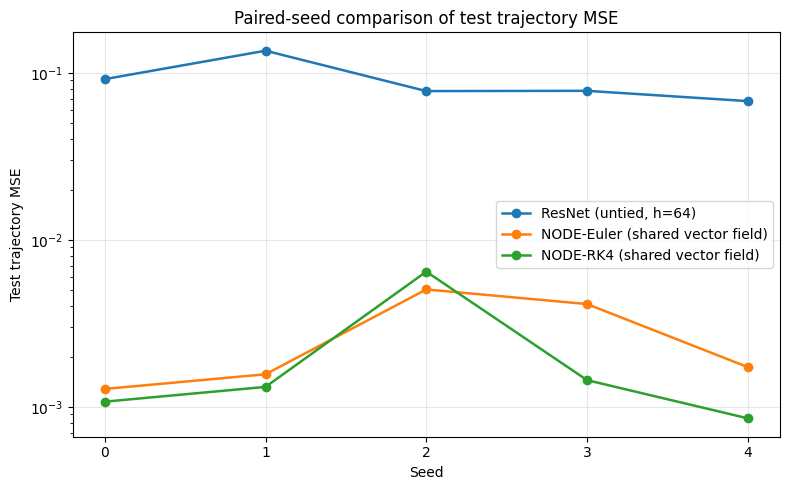

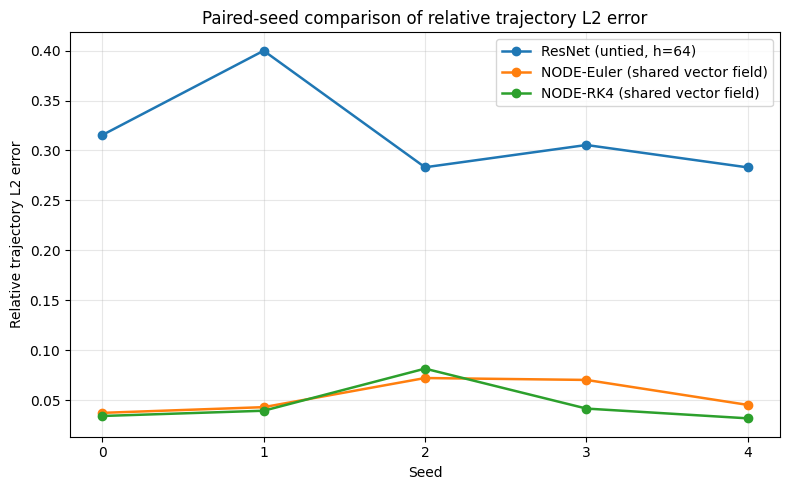

In [27]:
pretty = {k: MODEL_SPECS[k]["label"] for k in MODEL_ORDER}

# Paired-seed test loss
pivot_test = results_df.pivot(index="seed", columns="model", values="test_loss")[MAIN_MODEL_ORDER]

plt.figure(figsize=(8, 5))
for model in MAIN_MODEL_ORDER:
    plt.plot(pivot_test.index, pivot_test[model], marker="o", linewidth=1.8, label=pretty[model])
plt.yscale("log")
plt.xlabel("Seed")
plt.ylabel("Test trajectory MSE")
plt.title("Paired-seed comparison of test trajectory MSE")
plt.xticks(SEEDS)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
path = RESULTS_DIR / "paired_seed_test_loss.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

# Paired-seed relative L2 error
pivot_rel = results_df.pivot(index="seed", columns="model", values="test_rel_l2_err")[MAIN_MODEL_ORDER]

plt.figure(figsize=(8, 5))
for model in MAIN_MODEL_ORDER:
    plt.plot(pivot_rel.index, pivot_rel[model], marker="o", linewidth=1.8, label=pretty[model])
plt.xlabel("Seed")
plt.ylabel("Relative trajectory L2 error")
plt.title("Paired-seed comparison of relative trajectory L2 error")
plt.xticks(SEEDS)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
path = RESULTS_DIR / "paired_seed_rel_l2.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()


## Boxplot of test loss across seeds for the main three models


/var/folders/g9/zqlb1j1d6g15cvmc1d9q7c6c0000gn/T/ipykernel_41802/127574644.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


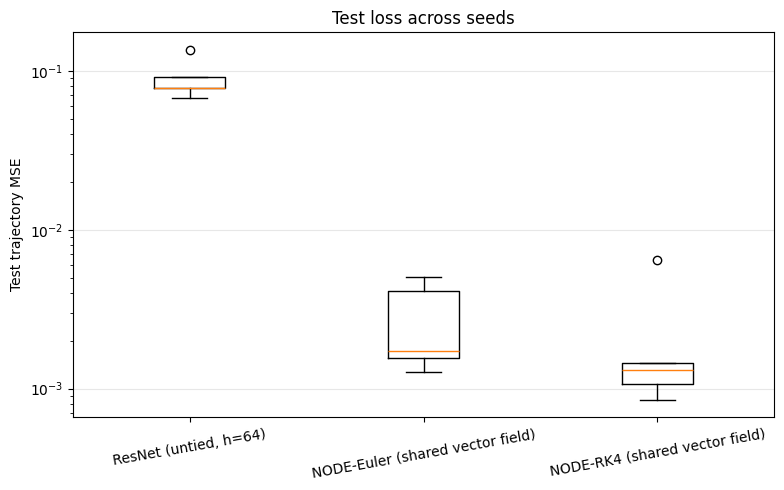

In [28]:
plt.figure(figsize=(8, 5))
data = [results_df.loc[results_df["model"] == m, "test_loss"].values for m in MAIN_MODEL_ORDER]
labels = [pretty[m] for m in MAIN_MODEL_ORDER]
plt.boxplot(data, labels=labels)
plt.yscale("log")
plt.ylabel("Test trajectory MSE")
plt.title("Test loss across seeds")
plt.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=10)
plt.tight_layout()
path = RESULTS_DIR / "boxplot_test_loss_main_models.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()


## Mean validation-loss curves across seeds

These curves help distinguish early optimization behavior from final accuracy.


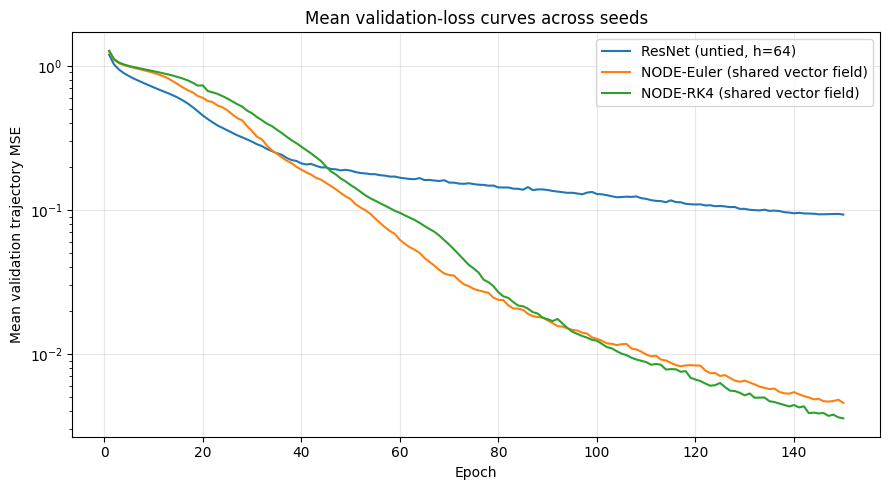

In [29]:
if histories_df is not None:
    grouped_hist = (
        histories_df.groupby(["model", "epoch"], as_index=False)
        .agg(
            train_loss_mean=("train_loss", "mean"),
            train_loss_std=("train_loss", "std"),
            val_loss_mean=("val_loss", "mean"),
            val_loss_std=("val_loss", "std"),
        )
    )

    grouped_hist = grouped_hist[grouped_hist["model"].isin(MAIN_MODEL_ORDER)]

    plt.figure(figsize=(9, 5))
    for model in MAIN_MODEL_ORDER:
        group = grouped_hist[grouped_hist["model"] == model]
        plt.plot(group["epoch"], group["val_loss_mean"], label=pretty[model])

    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Mean validation trajectory MSE")
    plt.title("Mean validation-loss curves across seeds")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    path = RESULTS_DIR / "mean_validation_loss_curves.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No histories available.")


## Cost summary

This plot combines:
- exact **forward operator evaluations per trajectory**
- measured **mean fit time**

It is meant to support a more numerically grounded discussion of runtime than wall-clock alone.


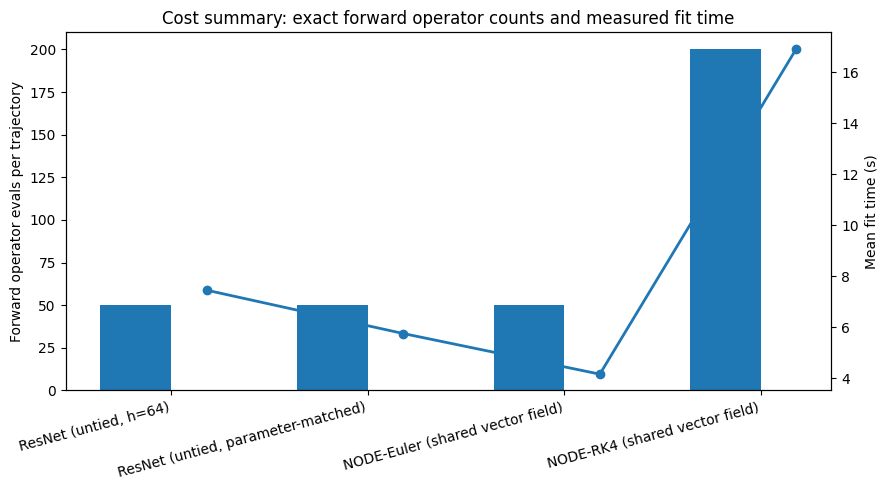

In [30]:
cost_plot_df = summary_df.set_index("model").loc[MODEL_ORDER].reset_index()

fig, ax1 = plt.subplots(figsize=(9, 5))
x = np.arange(len(cost_plot_df))

ax1.bar(x - 0.18, cost_plot_df["operator_evals_per_traj_forward"], width=0.36)
ax1.set_ylabel("Forward operator evals per trajectory")
ax1.set_xticks(x)
ax1.set_xticklabels(cost_plot_df["label"], rotation=15, ha="right")

ax2 = ax1.twinx()
ax2.plot(x + 0.18, cost_plot_df["fit_time_mean"], marker="o", linewidth=2)
ax2.set_ylabel("Mean fit time (s)")

plt.title("Cost summary: exact forward operator counts and measured fit time")
plt.tight_layout()
path = RESULTS_DIR / "cost_summary_plot.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()


## LaTeX rows for the main comparison table


In [31]:
latex_rows = []
for _, row in main_table_df.iterrows():
    latex_rows.append(
        (
            row["label"],
            int(row["parameters"]),
            row["test_loss_mean_pm_std"],
            row["test_rel_l2_err_mean_pm_std"],
            row["fit_time_mean_pm_std"],
        )
    )

for r in latex_rows:
    print(f"{r[0]} & {r[1]} & {r[2]} & {r[3]} & {r[4]} \\")


ResNet (untied, h=64) & 224100 & 0.090118 ± 0.026809 & 0.317419 ± 0.048224 & 7.453322 ± 0.158138 \
NODE-Euler (shared vector field) & 4482 & 0.002748 ± 0.001714 & 0.053572 ± 0.016359 & 4.156848 ± 0.067694 \
NODE-RK4 (shared vector field) & 4482 & 0.002226 ± 0.002370 & 0.045685 ± 0.020435 & 16.933560 ± 0.172112 \


## Exploratory post-training adaptive-solver probe

 This section partially bridges the gap by taking the **learned NODE vector fields** and integrating them with adaptive solvers after training.

This is **not** part of the supervised training objective. It is a post hoc numerical probe on the learned dynamics.


In [32]:
PROBE_SEED = SEEDS[0]
PROBE_NODE_MODELS = ["node_euler", "node_rk4"]
PROBE_SOLVERS = ["DOP853", "Radau"]

probe_grid = np.array(
    [
        [-2.0, -2.0], [-2.0, 0.0], [-2.0, 2.0],
        [0.0, -2.0],  [0.0, 0.0],  [0.0, 2.0],
        [2.0, -2.0],  [2.0, 0.0],  [2.0, 2.0],
    ],
    dtype=np.float64,
)

@torch.no_grad()
def make_numpy_vf(trained_model):
    trained_model.eval()
    def vf(t, z):
        z_t = torch.tensor(z, dtype=torch.float32, device=device).unsqueeze(0)
        out = trained_model.vf(z_t).squeeze(0).detach().cpu().numpy().astype(np.float64)
        return out
    return vf

def load_trained_model(model_name, seed):
    models = build_models()
    model = models[model_name].to(device)
    ckpt_path = RESULTS_DIR / f"{model_name}_seed{seed}.pt"
    checkpoint = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    return model

def benchmark_solver_on_learned_vf(trained_model, z0_list, method, rtol=1e-6, atol=1e-9):
    vf = make_numpy_vf(trained_model)
    rows = []
    for ic_id, z0 in enumerate(z0_list):
        t_start = time.perf_counter()
        sol = solve_ivp(
            fun=vf,
            t_span=(T0, T1),
            y0=np.asarray(z0, dtype=np.float64),
            method=method,
            t_eval=T_EVAL,
            rtol=rtol,
            atol=atol,
        )
        elapsed = time.perf_counter() - t_start
        rows.append(
            {
                "model": type(trained_model).__name__,
                "solver": method,
                "ic_id": ic_id,
                "z0_x": float(z0[0]),
                "z0_v": float(z0[1]),
                "success": bool(sol.success),
                "nfev": float(sol.nfev),
                "njev": float(getattr(sol, "njev", np.nan)),
                "nlu": float(getattr(sol, "nlu", np.nan)),
                "wall_time_sec": elapsed,
            }
        )
    return pd.DataFrame(rows)

probe_rows = []
for model_name in PROBE_NODE_MODELS:
    trained_model = load_trained_model(model_name, PROBE_SEED)
    for solver_name in PROBE_SOLVERS:
        bench_df = benchmark_solver_on_learned_vf(trained_model, probe_grid, method=solver_name)
        bench_df["probe_model"] = model_name
        probe_rows.append(bench_df)

probe_results_df = pd.concat(probe_rows, ignore_index=True)
probe_results_path = RESULTS_DIR / f"adaptive_solver_probe_seed{PROBE_SEED}.csv"
probe_results_df.to_csv(probe_results_path, index=False)

probe_summary_df = (
    probe_results_df.groupby(["probe_model", "solver"], as_index=False)
    .agg(
        success_rate=("success", "mean"),
        nfev_mean=("nfev", "mean"),
        nfev_std=("nfev", "std"),
        wall_time_mean=("wall_time_sec", "mean"),
        wall_time_std=("wall_time_sec", "std"),
    )
)
probe_summary_df


,probe_model,solver,success_rate,nfev_mean,nfev_std,wall_time_mean,wall_time_std
0,node_euler,DOP853,1.0,2236.666667,3815.453807,0.056743,0.094398
1,node_euler,Radau,1.0,3233.000000,1398.470861,0.112850,0.051531
2,node_rk4,DOP853,1.0,1827.000000,3891.508255,0.046419,0.097804
3,node_rk4,Radau,1.0,2367.222222,1272.979161,0.078910,0.048162


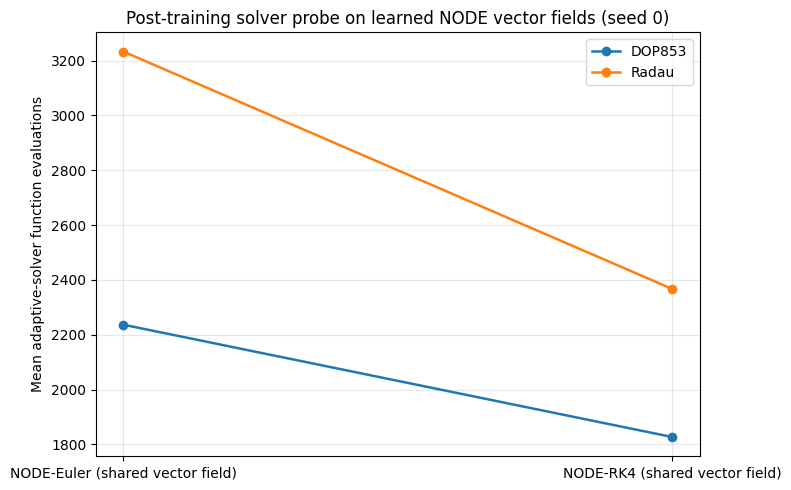

In [33]:
plt.figure(figsize=(8, 5))
for solver_name in PROBE_SOLVERS:
    sub = probe_summary_df[probe_summary_df["solver"] == solver_name]
    x = np.arange(len(sub))
    plt.plot(
        sub["probe_model"].map(pretty),
        sub["nfev_mean"],
        marker="o",
        linewidth=1.8,
        label=solver_name,
    )
plt.ylabel("Mean adaptive-solver function evaluations")
plt.title(f"Post-training solver probe on learned NODE vector fields (seed {PROBE_SEED})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
path = RESULTS_DIR / f"adaptive_solver_probe_seed{PROBE_SEED}.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
